Successfully loaded 6 systems. Using Base Rings = 1 for reference.


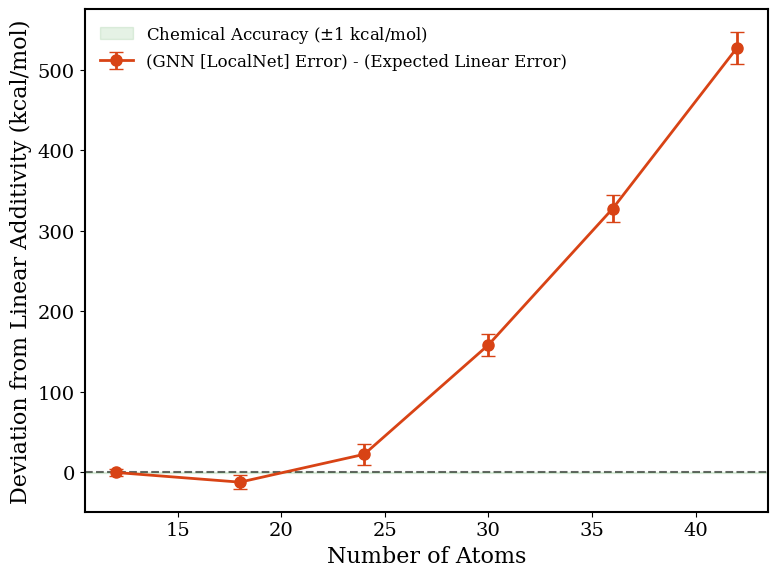

Maximum relative extensivity error: 527.14 kcal/mol


In [1]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from ipie.analysis.autocorr import reblock_by_autocorr

# =============================================================================
# 0. PUBLICATION PLOT SETTINGS
# =============================================================================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'font.family': 'serif',
    'figure.dpi': 100
})

HA_TO_KCAL = 627.509

# =============================================================================
# 1. BULLETPROOF DATA EXTRACTION
# =============================================================================
data = []
dirs = glob.glob("A_[1-6]")

for d in dirs:
    try:
        n_rings = int(d.split('_')[1])
        gnn_file = os.path.join(d, f"scaling_metrics_GNN_A_{n_rings}.json")
        classical_file = os.path.join(d, f"scaling_metrics_Classical_A_{n_rings}.json")
        
        if os.path.exists(gnn_file) and os.path.exists(classical_file):
            with open(gnn_file, 'r') as f: gnn_m = json.load(f)
            with open(classical_file, 'r') as f: class_m = json.load(f)
            
            data.append({"N_rings": n_rings, "gnn": gnn_m, "classical": class_m})
    except Exception as e:
        pass

data = sorted(data, key=lambda x: x["N_rings"])

valid_data = []
for d in data:
    has_gnn_blocks = "raw_block_energies" in d["gnn"].get("results", {})
    has_class_blocks = "raw_block_energies" in d["classical"].get("results", {})
    
    if has_gnn_blocks and has_class_blocks:
        valid_data.append(d)
    else:
        print(f"⚠️ Warning: 'raw_block_energies' missing for Acene_{d['N_rings']}. Skipping.")

data = valid_data 

N_rings = np.array([d["N_rings"] for d in data])
total_atoms = 6 * N_rings + 6 

if len(total_atoms) == 0:
    print("Error: No valid JSON files with 'raw_block_energies' found. Exiting.")
    exit()

# =============================================================================
# 2. PAIRED ENERGY DIFFERENCE EXTRACTION
# =============================================================================
diff_E_list, diff_err_list = [], []

for d in data:
    raw_gnn = np.array(d["gnn"]["results"]["raw_block_energies"]).flatten()
    raw_class = np.array(d["classical"]["results"]["raw_block_energies"]).flatten()
    
    # Paired array subtraction for correlated Monte Carlo runs
    e_diff_array = raw_gnn - raw_class
    
    try:
        df_diff = reblock_by_autocorr(e_diff_array, name="E_Diff", verbose=0)
    except TypeError:
        df_diff = reblock_by_autocorr(e_diff_array, verbose=0)
        
    diff_E_list.append(float(df_diff.iloc[0, 0]))
    diff_err_list.append(float(df_diff.iloc[0, 1]))

diff_E = np.array(diff_E_list)
diff_err = np.array(diff_err_list)

# =============================================================================
# 3. HOMODESMOTIC SIZE EXTENSIVITY MATHEMATICS
# =============================================================================
BASE_RINGS = N_rings[0]
print(f"Successfully loaded {len(N_rings)} systems. Using Base Rings = {BASE_RINGS} for reference.")

# Scale based on the repeating C4H2 bulk unit (number of rings)
scaling_factors = N_rings / BASE_RINGS

# Relative Deviation: \Delta E(N) - (N_rings / Base_rings) * \Delta E(Base_rings)
relative_ext_diff = (diff_E - (scaling_factors * diff_E[0])) * HA_TO_KCAL

# Error Propagation
prop_err_diff = np.sqrt(diff_err**2 + (scaling_factors * diff_err[0])**2) * HA_TO_KCAL

# =============================================================================
# 4. PLOTTING THE DIFFERENCE
# =============================================================================
c_diff = '#D84315' # Distinct burnt orange for acenes
cap = 5

os.makedirs("acene_publication_plots", exist_ok=True)

plt.figure(figsize=(8, 6))

plt.errorbar(total_atoms, relative_ext_diff, yerr=prop_err_diff, fmt='-o', 
             color=c_diff, capsize=cap, lw=2.0, ms=8,
             label='(GNN [LocalNet] Error) - (Expected Linear Error)', zorder=2)

# Reference line at 0 (Perfect Size Extensivity relative to baseline)
plt.axhline(0, color='black', lw=1.5, ls='--', alpha=0.6, zorder=1)
plt.axhspan(-1.0, 1.0, color='green', alpha=0.1, label=r'Chemical Accuracy ($\pm$1 kcal/mol)')

plt.xlabel('Number of Atoms')
plt.ylabel('Deviation from Linear Additivity (kcal/mol)')
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig("acene_publication_plots/Acene_Extensivity_Difference.pdf", bbox_inches='tight')
plt.show()

max_diff = np.max(np.abs(relative_ext_diff))
print(f"Maximum relative extensivity error: {max_diff:.2f} kcal/mol")

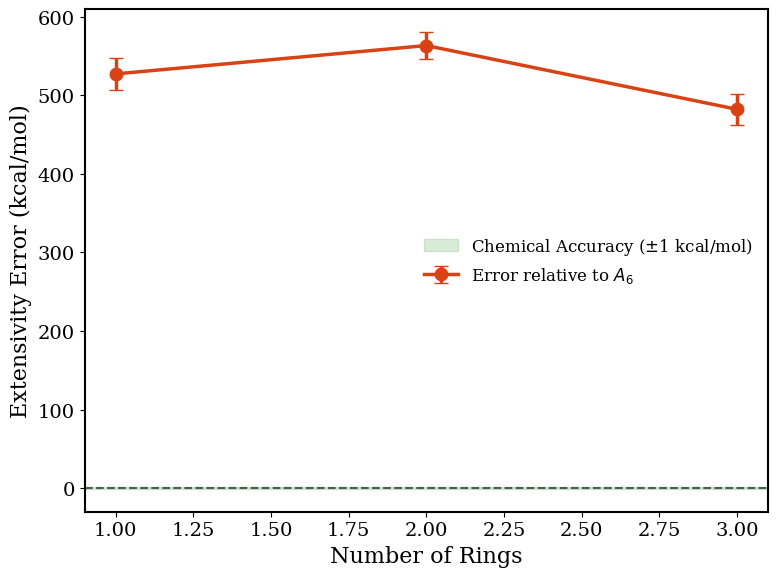

In [7]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from ipie.analysis.autocorr import reblock_by_autocorr

# =============================================================================
# 0. PUBLICATION PLOT SETTINGS
# =============================================================================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'font.family': 'serif',
    'figure.dpi': 100
})

HA_TO_KCAL = 627.509

# =============================================================================
# 1. BULLETPROOF DATA EXTRACTION
# =============================================================================
data = []
dirs = glob.glob("A_[1-6]")

for d in dirs:
    try:
        n_rings = int(d.split('_')[1])
        gnn_file = os.path.join(d, f"scaling_metrics_GNN_A_{n_rings}.json")
        classical_file = os.path.join(d, f"scaling_metrics_Classical_A_{n_rings}.json")
        
        if os.path.exists(gnn_file) and os.path.exists(classical_file):
            with open(gnn_file, 'r') as f: gnn_m = json.load(f)
            with open(classical_file, 'r') as f: class_m = json.load(f)
            
            data.append({"N_rings": n_rings, "gnn": gnn_m, "classical": class_m})
    except Exception as e:
        pass

data = sorted(data, key=lambda x: x["N_rings"])

valid_data = []
for d in data:
    has_gnn_blocks = "raw_block_energies" in d["gnn"].get("results", {})
    has_class_blocks = "raw_block_energies" in d["classical"].get("results", {})
    
    if has_gnn_blocks and has_class_blocks:
        valid_data.append(d)
    else:
        print(f"⚠️ Warning: 'raw_block_energies' missing for Acene_{d['N_rings']}. Skipping.")

data = valid_data 
N_rings = np.array([d["N_rings"] for d in data])

if len(N_rings) == 0:
    print("Error: No valid JSON files found. Exiting.")
    exit()

# =============================================================================
# 2. PAIRED ENERGY DIFFERENCE EXTRACTION
# =============================================================================
diff_E_list, diff_err_list = [], []

for d in data:
    raw_gnn = np.array(d["gnn"]["results"]["raw_block_energies"]).flatten()
    raw_class = np.array(d["classical"]["results"]["raw_block_energies"]).flatten()
    
    # Paired array subtraction for correlated Markov chain blocks
    e_diff_array = raw_gnn - raw_class
    
    try:
        df_diff = reblock_by_autocorr(e_diff_array, name="E_Diff", verbose=0)
    except TypeError:
        df_diff = reblock_by_autocorr(e_diff_array, verbose=0)
        
    diff_E_list.append(float(df_diff.iloc[0, 0]))
    diff_err_list.append(float(df_diff.iloc[0, 1]))

diff_E = np.array(diff_E_list)
diff_err = np.array(diff_err_list)

# =============================================================================
# 3. CONVERGENCE TO FIXED MACROSCOPIC TARGET (A_6)
# =============================================================================
TARGET_RINGS = 6  # Setting Hexacene as our macroeconomic benchmark target

if TARGET_RINGS not in N_rings:
    print(f"Error: Target N_rings={TARGET_RINGS} not found in data.")
    exit()

target_idx = np.where(N_rings == TARGET_RINGS)[0][0]
target_diff_E = diff_E[target_idx]
target_diff_err = diff_err[target_idx]

# Reference sizes we want to test extrapolation capability from
test_base_sizes = [1, 2, 3] 

base_sizes_plotted = []
extensivity_errors = []
extensivity_error_bars = []

for base_n in test_base_sizes:
    if base_n in N_rings:
        base_idx = np.where(N_rings == base_n)[0][0]
        
        # Scaling factor based on structural composition
        scale_factor = TARGET_RINGS / base_n
        
        # Consistent metric matching the hydrogen workflow
        dev_at_target = (target_diff_E - (scale_factor * diff_E[base_idx])) * HA_TO_KCAL
        err_at_target = np.sqrt(target_diff_err**2 + (scale_factor * diff_err[base_idx])**2) * HA_TO_KCAL
        
        base_sizes_plotted.append(base_n)
        extensivity_errors.append(dev_at_target) 
        extensivity_error_bars.append(err_at_target)

base_sizes_plotted = np.array(base_sizes_plotted)
extensivity_errors = np.array(extensivity_errors)
extensivity_error_bars = np.array(extensivity_error_bars)

# =============================================================================
# 4. PLOTTING THE PI-EXTRAPOLATION CONVERGENCE
# =============================================================================
c_decay = '#D84315' # Burnt Orange for Acenes
cap = 5

os.makedirs("publication_plots", exist_ok=True)
plt.figure(figsize=(8, 6))

plt.errorbar(base_sizes_plotted, extensivity_errors, yerr=extensivity_error_bars, 
             fmt='-o', color=c_decay, capsize=cap, lw=2.5, markersize=9, 
             label=f'Error relative to $A_{{{TARGET_RINGS}}}$')

plt.axhline(0, color='black', lw=1.5, ls='--', alpha=0.6)
plt.axhspan(-1.0, 1.0, color='green', alpha=0.15, label=r'Chemical Accuracy ($\pm$1 kcal/mol)')

plt.xlabel('Number of Rings')
plt.ylabel('Extensivity Error (kcal/mol)')
plt.legend(frameon=False, loc='center right')
plt.tight_layout()

plt.savefig("publication_plots/Acene_Thermodynamic_Convergence.pdf", bbox_inches='tight')
plt.show()

Acene publication-ready plots saved to 'acene_publication_plots/'.


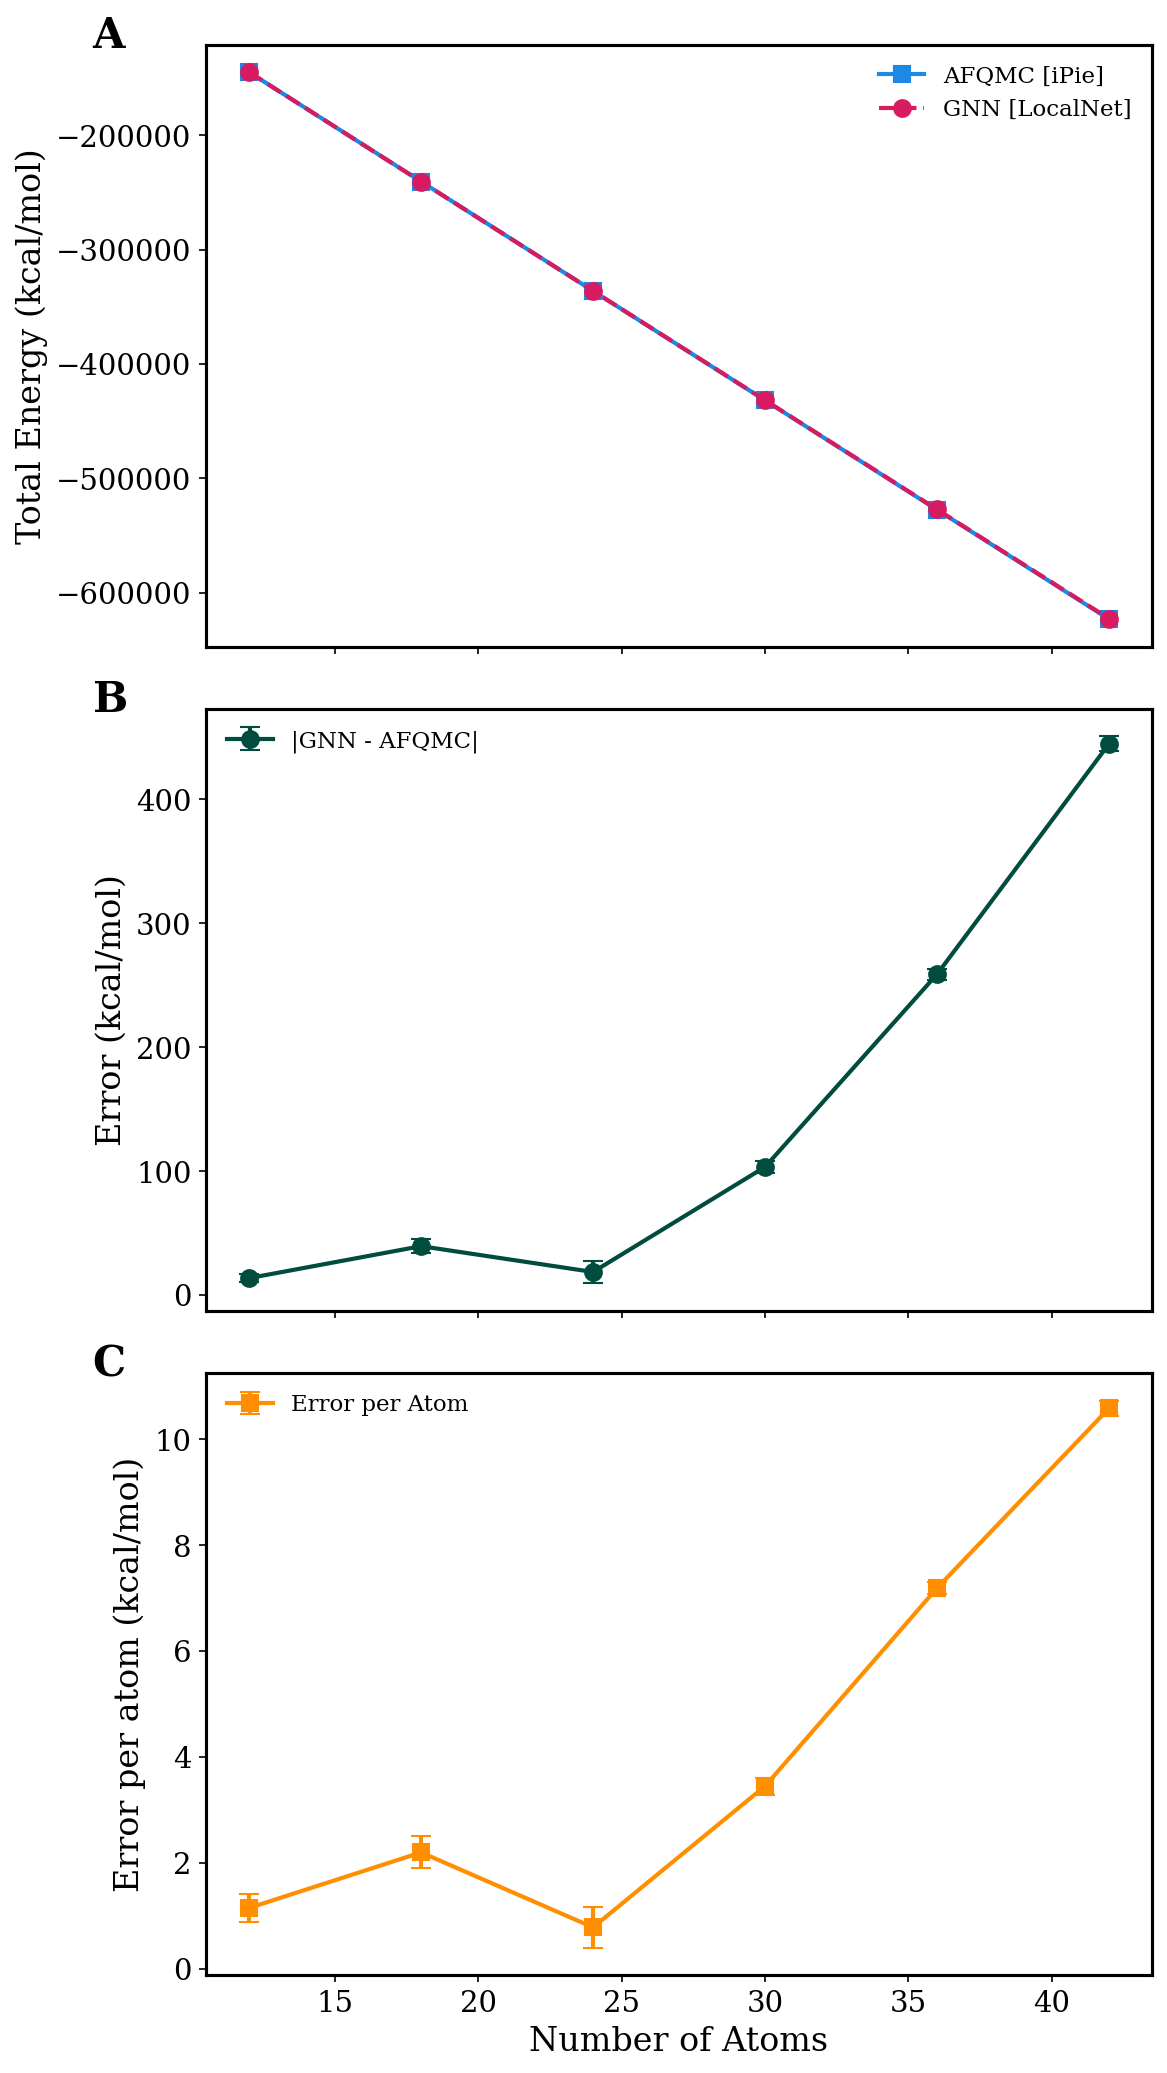

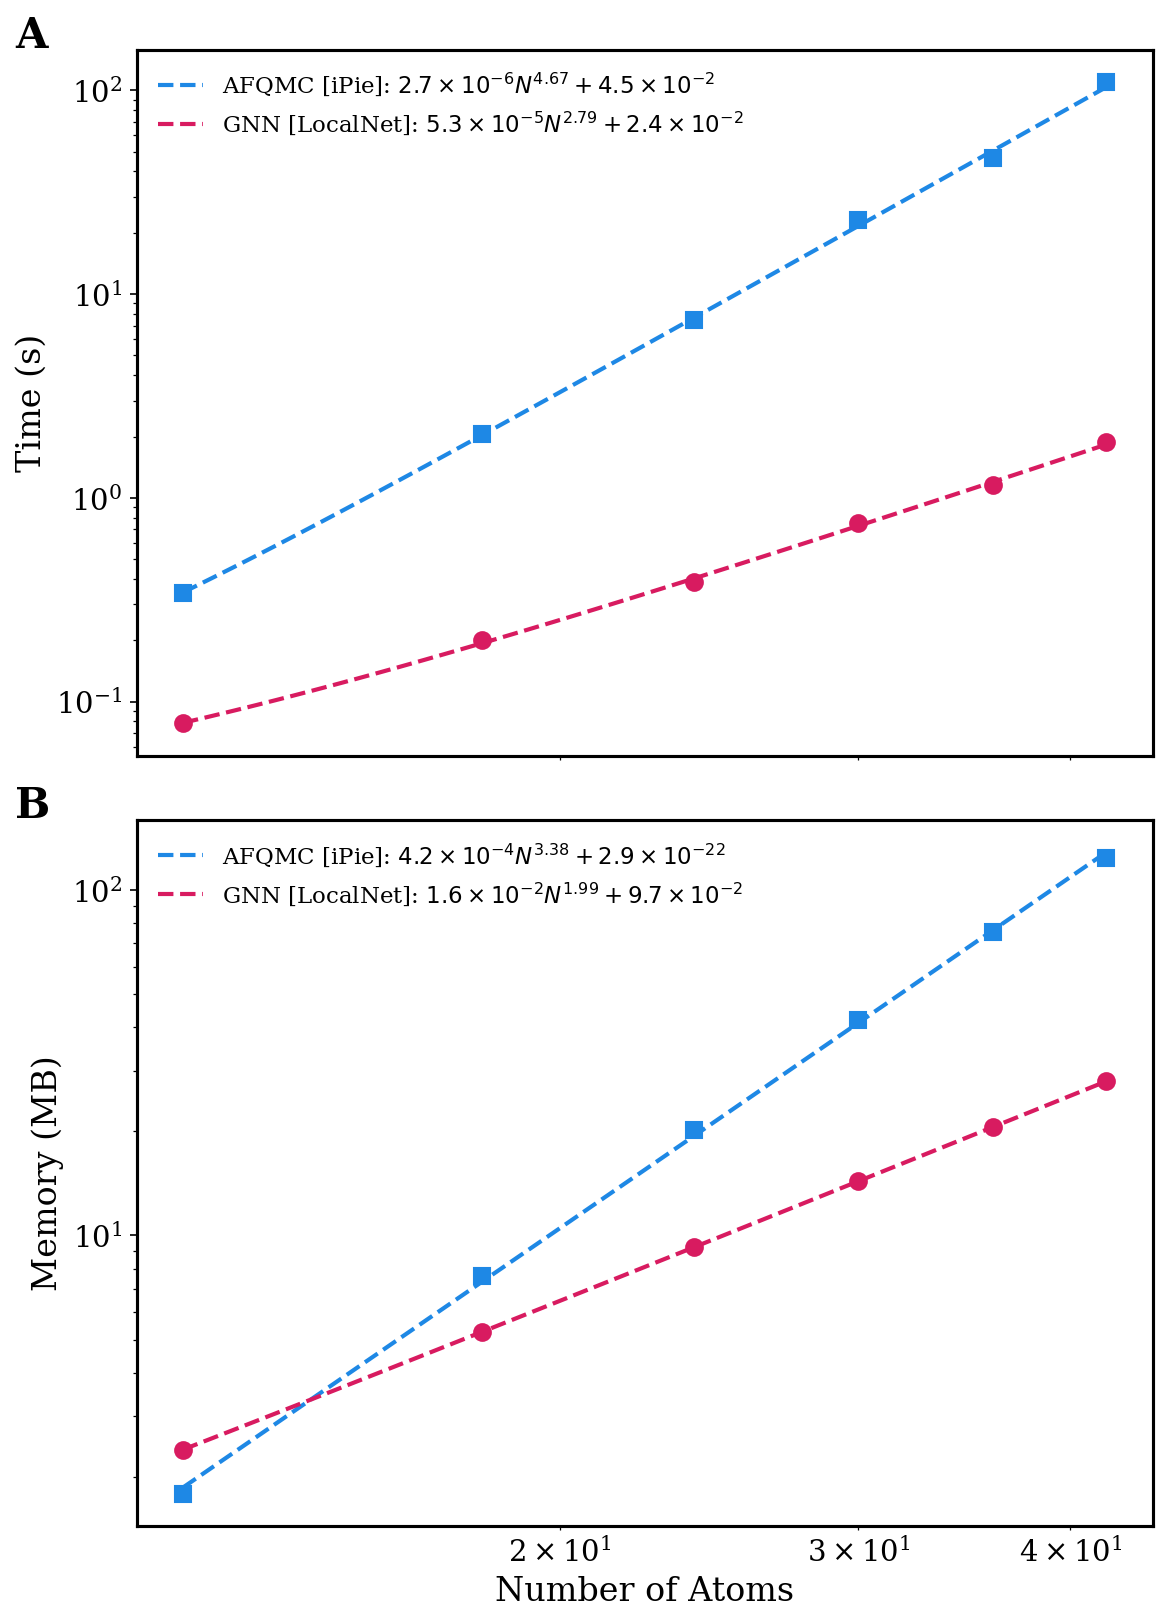

In [2]:
import os, glob, json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from ipie.analysis.autocorr import reblock_by_autocorr

# =============================================================================
# 0. PUBLICATION PLOT SETTINGS
# =============================================================================
plt.rcParams.update({
    'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 14,
    'ytick.labelsize': 14, 'legend.fontsize': 11, 'axes.linewidth': 1.5,
    'lines.linewidth': 2.0, 'lines.markersize': 8, 'font.family': 'serif',
    'figure.dpi': 150
})

HA_TO_KCAL = 627.509
c_gnn, c_class = '#D81B60', '#1E88E5'

def power_law_with_overhead(x, a, b, c):
    return a * (x**b) + c

def get_scaling_exponent(x, y):
    if len(x) < 3: return np.array([]), np.array([]), 0, 0, 0
    p0 = [1e-5, 3.0, min(y) * 0.1]
    bounds = ([0, 0, 0], [np.inf, 10.0, min(y)])
    try:
        popt, _ = curve_fit(power_law_with_overhead, x, y, p0=p0, bounds=bounds, 
                             sigma=y, absolute_sigma=False, maxfev=50000)
        a, b, c = popt
    except:
        b, log_a = np.polyfit(np.log(x), np.log(y), 1)
        a, c = np.exp(log_a), 0
    x_fit = np.geomspace(min(x), max(x), 100)
    y_fit = power_law_with_overhead(x_fit, a, b, c)
    return x_fit, y_fit, a, b, c

def format_sci_latex(num):
    """Converts a number from 'e' format into proper LaTeX scientific notation."""
    if num == 0:
        return "0"
    s = f"{num:.1e}"
    base, exponent = s.split('e')
    return f"{base} \\times 10^{{{int(exponent)}}}"

def add_panel_label(ax, label):
    ax.text(-0.12, 1.05, label, transform=ax.transAxes, fontsize=20, fontweight='bold', va='top')

# --- Data Extraction (Acene Logic) ---
data_list = []
dirs = sorted(glob.glob("A_[1-6]"), key=lambda x: int(x.split('_')[1]))
N_at, t_gnn, t_cls, m_gnn, m_cls, e_diff, e_err, e_gnn, e_cls = [], [], [], [], [], [], [], [], []

for d in dirs:
    try:
        n = int(d.split('_')[1])
        with open(os.path.join(d, f"scaling_metrics_GNN_A_{n}.json")) as f: g_m = json.load(f)
        with open(os.path.join(d, f"scaling_metrics_Classical_A_{n}.json")) as f: c_m = json.load(f)
        
        rg, rc = np.array(g_m["results"]["raw_block_energies"]), np.array(c_m["results"]["raw_block_energies"])
        N_at.append(6*n+6)
        e_gnn.append(np.mean(rg)); e_cls.append(np.mean(rc))
        
        diff_ac = reblock_by_autocorr((rg - rc).flatten(), verbose=0)
        e_diff.append(np.abs(float(diff_ac.iloc[0, 0])) * HA_TO_KCAL)
        e_err.append(float(diff_ac.iloc[0, 1]) * HA_TO_KCAL)
        
        t_gnn.append(g_m["local_energy_proxy"]["avg_time_sec"])
        t_cls.append(c_m["local_energy_proxy"]["avg_time_sec"])
        m_gnn.append(g_m["local_energy_proxy"].get("total_intrinsic_memory_mb", 10))
        m_cls.append(c_m["local_energy_proxy"].get("total_intrinsic_memory_mb", 10))
    except: continue

N_at = np.array(N_at)
os.makedirs("acene_publication_plots", exist_ok=True)

# 1. ACCURACY COMBINED STACK (FIGURE 1)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 14), sharex=True)

e_cls_kcal = np.array(e_cls) * HA_TO_KCAL
e_gnn_kcal = np.array(e_gnn) * HA_TO_KCAL

# Panel A: Total Energy
ax1.plot(N_at, e_cls_kcal, 's-', color=c_class, label='AFQMC [iPie]')
ax1.plot(N_at, e_gnn_kcal, 'o--', color=c_gnn, label='GNN [LocalNet]')
ax1.set_ylabel('Total Energy (kcal/mol)')
ax1.legend(frameon=False)
add_panel_label(ax1, "A")

# Panel B: Error
ax2.errorbar(N_at, e_diff, yerr=e_err, fmt='-o', color='#004D40', capsize=5, label='|GNN - AFQMC|')
ax2.set_ylabel('Error (kcal/mol)')
ax2.legend(frameon=False)
add_panel_label(ax2, "B")

# Panel C: Error per Atom
ax3.errorbar(N_at, np.array(e_diff)/N_at, yerr=np.array(e_err)/N_at, fmt='-s', color='#FF8F00', capsize=5, label='Error per Atom')
ax3.set_xlabel('Number of Atoms')
ax3.set_ylabel('Error per atom (kcal/mol)')
ax3.legend(frameon=False)
add_panel_label(ax3, "C")

plt.tight_layout(); plt.savefig("acene_publication_plots/Acene_Accuracy_Combined.pdf")

# 2. SCALING STACK (FIGURE 2)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 11), sharex=True)

# Panel A: Time Scaling
xf, yf, a, b, c = get_scaling_exponent(N_at, t_cls)
ax1.plot(N_at, t_cls, 's', color=c_class)
ax1.plot(xf, yf, '--', color=c_class, label=fr'AFQMC [iPie]: ${format_sci_latex(a)}N^{{{b:.2f}}} + {format_sci_latex(c)}$')

xf, yf, a, b, c = get_scaling_exponent(N_at, t_gnn)
ax1.plot(N_at, t_gnn, 'o', color=c_gnn)
ax1.plot(xf, yf, '--', color=c_gnn, label=fr'GNN [LocalNet]: ${format_sci_latex(a)}N^{{{b:.2f}}} + {format_sci_latex(c)}$')
ax1.set_yscale('log')
ax1.set_ylabel('Time (s)')
ax1.legend(frameon=False)
add_panel_label(ax1, "A")

# Panel B: Memory Scaling
xf, yf, a, b, c = get_scaling_exponent(N_at, m_cls)
ax2.plot(N_at, m_cls, 's', color=c_class)
ax2.plot(xf, yf, '--', color=c_class, label=fr'AFQMC [iPie]: ${format_sci_latex(a)}N^{{{b:.2f}}} + {format_sci_latex(c)}$')

xf, yf, a, b, c = get_scaling_exponent(N_at, m_gnn)
ax2.plot(N_at, m_gnn, 'o', color=c_gnn)
ax2.plot(xf, yf, '--', color=c_gnn, label=fr'GNN [LocalNet]: ${format_sci_latex(a)}N^{{{b:.2f}}} + {format_sci_latex(c)}$')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Atoms')
ax2.set_ylabel('Memory (MB)')
ax2.legend(frameon=False)
add_panel_label(ax2, "B")

plt.tight_layout(); plt.savefig("acene_publication_plots/Acene_Scaling_Combined.pdf")

print("Acene publication-ready plots saved to 'acene_publication_plots/'.")

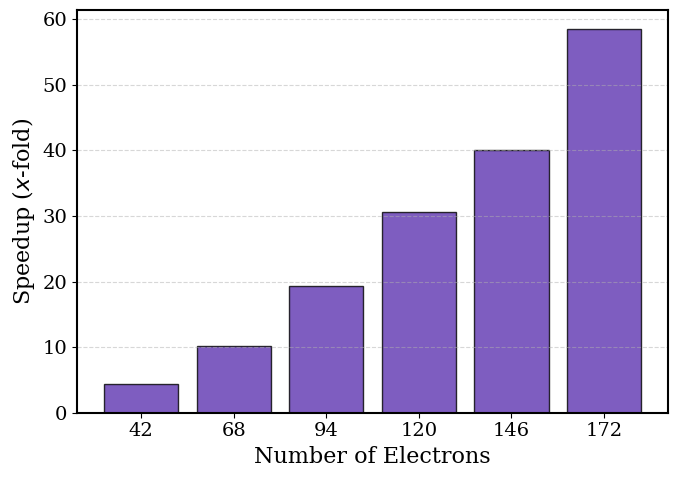

All individual acene plots successfully saved to the 'acene_publication_plots' directory.


In [3]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from ipie.analysis.autocorr import reblock_by_autocorr

# =============================================================================
# 0. PUBLICATION PLOT SETTINGS
# =============================================================================
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'font.family': 'serif', # Standard for LaTeX publications
    'figure.dpi': 100       # Screen DPI for plt.show()
})

HA_TO_KCAL = 627.509

data = []
dirs = glob.glob("A_[1-6]")

for d in dirs:
    try:
        n_rings = int(d.split('_')[1])
        gnn_file = os.path.join(d, f"scaling_metrics_GNN_A_{n_rings}.json")
        classical_file = os.path.join(d, f"scaling_metrics_Classical_A_{n_rings}.json")
        
        if os.path.exists(gnn_file) and os.path.exists(classical_file):
            with open(gnn_file, 'r') as f: gnn_m = json.load(f)
            with open(classical_file, 'r') as f: class_m = json.load(f)
            
            data.append({"N_rings": n_rings, "gnn": gnn_m, "classical": class_m})
    except Exception as e:
        print(f"Skipping {d}: {e}")

data = sorted(data, key=lambda x: x["N_rings"])

# =============================================================================
# 2. DATA UNPACKING & RIGOROUS ERROR PROPAGATION
# =============================================================================
valid_data = []
for d in data:
    has_gnn_blocks = "raw_block_energies" in d["gnn"].get("results", {})
    has_class_blocks = "raw_block_energies" in d["classical"].get("results", {})
    
    if has_gnn_blocks and has_class_blocks:
        valid_data.append(d)
    else:
        print(f"Warning: 'raw_block_energies' missing for Acene_{d['N_rings']}. Skipping.")

data = valid_data 

# Define absolute atom and electron counts for x-axes
N_rings = np.array([d["N_rings"] for d in data])
total_atoms = 6 * N_rings + 6 

# Acene formula: C_{4n+2}H_{2n+4}
# Electrons = 6*(4n+2) + 1*(2n+4) = 26n + 16
total_electrons = 26 * N_rings + 16

if len(total_atoms) == 0:
    print("Error: No valid JSON files with 'raw_block_energies' found. Exiting.")
    exit()

def safe_extract(d, backend, key):
    proxy = d[backend].get("local_energy_proxy", {})
    val = proxy.get(key)
    if val is None and backend == "gnn" and key == "total_intrinsic_memory_mb":
        return proxy.get("model_weights_mb", 0.0) + proxy.get("graph_batch_mb", 0.0)
    return val if val is not None else 0.0

time_gnn = np.array([safe_extract(d, "gnn", "avg_time_sec") for d in data])
time_class = np.array([safe_extract(d, "classical", "avg_time_sec") for d in data])

mem_gnn = np.array([safe_extract(d, "gnn", "total_intrinsic_memory_mb") for d in data])
mem_class = np.array([safe_extract(d, "classical", "total_intrinsic_memory_mb") for d in data])

energy_diff_kcal_list = []
energy_err_kcal_list = []

for d in data:
    raw_gnn = np.array(d["gnn"]["results"]["raw_block_energies"])
    raw_class = np.array(d["classical"]["results"]["raw_block_energies"])
    e_diff = (raw_gnn - raw_class).flatten()
    
    try:
        df_diff_ac = reblock_by_autocorr(e_diff, name="E_Diff", verbose=0)
    except TypeError:
        df_diff_ac = reblock_by_autocorr(e_diff, verbose=0)
        
    mean_diff_ha = float(df_diff_ac.iloc[0, 0])
    error_diff_ha = float(df_diff_ac.iloc[0, 1])
    
    energy_diff_kcal_list.append(np.abs(mean_diff_ha) * HA_TO_KCAL)
    energy_err_kcal_list.append(error_diff_ha * HA_TO_KCAL)

energy_diff_kcal = np.array(energy_diff_kcal_list)
energy_err_kcal = np.array(energy_err_kcal_list)

error_per_atom_kcal = energy_diff_kcal / total_atoms
err_per_atom_bars_kcal = energy_err_kcal / total_atoms

# =============================================================================
# 3. INDIVIDUAL PLOTTING
# =============================================================================
c_gnn, c_class = '#D81B60', '#1E88E5'
cap = 5

os.makedirs("acene_publication_plots", exist_ok=True)

# --- Plot 5: Speedup Factor ---
plt.figure(figsize=(7, 5))
speedup = time_class / time_gnn
plt.bar(total_electrons.astype(str), speedup, color='#5E35B1', alpha=0.8, edgecolor='black')
plt.xlabel('Number of Electrons')
plt.ylabel('Speedup ($x$-fold)')
plt.grid(axis='y', ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("acene_publication_plots/Acene_Speedup_Factor.pdf", bbox_inches='tight')
plt.show()

print("All individual acene plots successfully saved to the 'acene_publication_plots' directory.")